In [1]:
%load_ext autoreload
%autoreload 2
import  emcee
import  numpy                   as np
import  matplotlib.pyplot       as plt
from    math                    import inf
from    pathlib                 import Path

# Top-hat jet model specific modules
from    maggpy.top_hat.montecarlo      import montecarlo, start_mcmc, apply_detection_cuts
from    maggpy.top_hat.plot            import TopHatPlotter
from    maggpy.utils                   import create_run_dir, score_func_cvm, poiss_log
from    maggpy.top_hat.init            import initialize_bns_simulation
from    maggpy.top_hat.geometric_eff   import geometric_efficiency_flat

# Apply custom plotting style
# plt.style.use('../configurations/style.mplstyle') if you have latex
# conda install -n acme_env -c conda-forge texlive-core dvipng cm-super if you want to use the latex style, otherwise use the default matplotlib style or a custom one without latex support. 

In [2]:
PARAM_NAMES = ["A_index", "L_L0", "L_mu_E", "sigma_E", "fj"]

def log_prior_flat_tophat(thetas):
    """Flat (uniform) prior for the top-hat model."""
    A_index, L_L0, L_mu_E, sigma_E, fj = thetas

    if not (1.5 < A_index       < 12):  return -inf
    if not (-2  < L_L0          < 7):   return -inf
    if not (0.1 < L_mu_E        < 7):   return -inf
    if not (0   < sigma_E       < 2.5): return -inf
    if not (0   < fj            < 10):   return -inf
    return 0.0

print("Prior test (valid point):",   log_prior_flat_tophat([3, 1, 3, 0.5, 0.5]))
print("Prior test (invalid point):", log_prior_flat_tophat([3, 1, 3, 0.5, 11]))

Prior test (valid point): 0.0
Prior test (invalid point): -inf


In [3]:
THETA_C_MAX = 25
def log_likelihood_flat_tophat(thetas, bns_data, observables, n_events=10_000):
    """Log-likelihood for the flat top-hat model."""
    fj                      = thetas[4]

    theta_c_max             = THETA_C_MAX 

    gbm_eff                 = 0.6
    geometric_efficiency    = geometric_efficiency_flat(theta_c_max, theta_c_min=0.5)
    triggered_years         = observables['trigger_years']
    epsilon                 = geometric_efficiency * fj

    n_years                 = triggered_years
    intrinsic_rate          = epsilon * len(bns_data.z_arr) * gbm_eff
    expected_events         = intrinsic_rate * n_years

    # Run the simplified Monte Carlo
    results                 = montecarlo(thetas, n_events, bns_data) 

    # Apply detection cuts
    trigger_mask, analysis_mask = apply_detection_cuts(results["p_flux"], results["E_p_obs"])

    if np.sum(analysis_mask)    <= 3: return -inf, -inf, -inf, -inf, -inf

    triggered_events            = np.sum(trigger_mask)
    physics_efficiency          = triggered_events / n_events
    predicted_detections        = expected_events * physics_efficiency
    observed_detections         = observables["c_det"] * triggered_years

    # Score functions
    l1 = score_func_cvm(results["p_flux"][analysis_mask].astype(np.float64), observables['pflux'])
    l2 = score_func_cvm(results["E_p_obs"][analysis_mask].astype(np.float64), observables['epeak'])
    l3 = poiss_log(k=observed_detections, mu=predicted_detections)

    return l1 + l2 + l3, l1, l2, l3, physics_efficiency

In [4]:
def initialize_walkers_flat(n_walkers):
    """Initialize walkers within the prior bounds."""
    np.random.seed(42)
    return np.column_stack([
        np.random.uniform(2, 3, n_walkers),        # A_index
        np.random.uniform(2, 4, n_walkers),        # L_L0
        np.random.uniform(2, 4, n_walkers),        # L_mu_E
        np.random.uniform(0.2, 1, n_walkers),      # sigma_E
        np.random.uniform(0.3, 0.8, n_walkers),    # fj
    ])

print(f"Example initial walker: {initialize_walkers_flat(1)[0]}")

Example initial walker: [2.37454012 3.90142861 3.46398788 0.67892679 0.37800932]


## Run MCMC

In [5]:
datafiles   = Path("../datafiles")
# Initialize simulation (loads GBM data, creates interpolators)
mrd_path                 = datafiles / "MRD_outputs/fiducial_A1_0_BNS.csv"
bns_data, observables    = initialize_bns_simulation(datafiles, mrd_path=mrd_path)

Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 333, Trigger years: 17.94, Yearly rate: 18.57 events/year
BNS: R(z=0.01)=113.74 Gpc^-3 yr^-1; all-sky rate=3.568e+05 yr^-1; MC sample=356797


In [6]:
def log_probability(thetas):
    lp = log_prior_flat_tophat(thetas)
    if not np.isfinite(lp):
        return -inf, 0, 0, 0, 0
    
    l_out = log_likelihood_flat_tophat(thetas, bns_data, observables)	
    if not np.isfinite(l_out[0]):
        return -inf, 0, 0, 0, 0
    
    return lp + l_out[0], l_out[1], l_out[2], l_out[3], l_out[4]

example_values_valid = [3, 1, 3, 0.5, 0.5]
print("Log-probability test (valid point):", log_probability(example_values_valid))

Log-probability test (valid point): (-591.9804451590328, -8.823457666151544, -20.50169071186887, -562.6552967810123, 0.0004)


In [13]:
# Create output directory and configure MCMC
output_dir  = create_run_dir("giulia_gianfa")

n_walkers   = 20
n_steps     = 100_005  # Use more steps (e.g. 50 000) for production runs

sampler = start_mcmc(log_probability_func=log_probability,
                     initialize_walkers_func=initialize_walkers_flat, 
                     n_iterations=n_steps, n_walkers=n_walkers, backend_fn=output_dir / "emcee.h5", n_params=len(PARAM_NAMES))

Loading existing directory  : Output_files/giulia_gianfa
Continuing from iteration 53225


 47%|████▋     | 21915/46780 [28:12<31:59, 12.95it/s] 


KeyboardInterrupt: 

## CDFs and Diagnostics

The `TopHatPlotter` provides all the standard diagnostic plots.

In [14]:
backend_flat    = emcee.backends.HDFBackend(output_dir / "emcee.h5")
BURN_IN         = 200

plotter = TopHatPlotter(
    backend     = backend_flat,
    output_dir  = output_dir,
    model_type  = "THETA_C_FLAT_UNIQUE",
    burn_in     = BURN_IN,
    thin        = 10
)

### Corner Plot

(106040, 5)


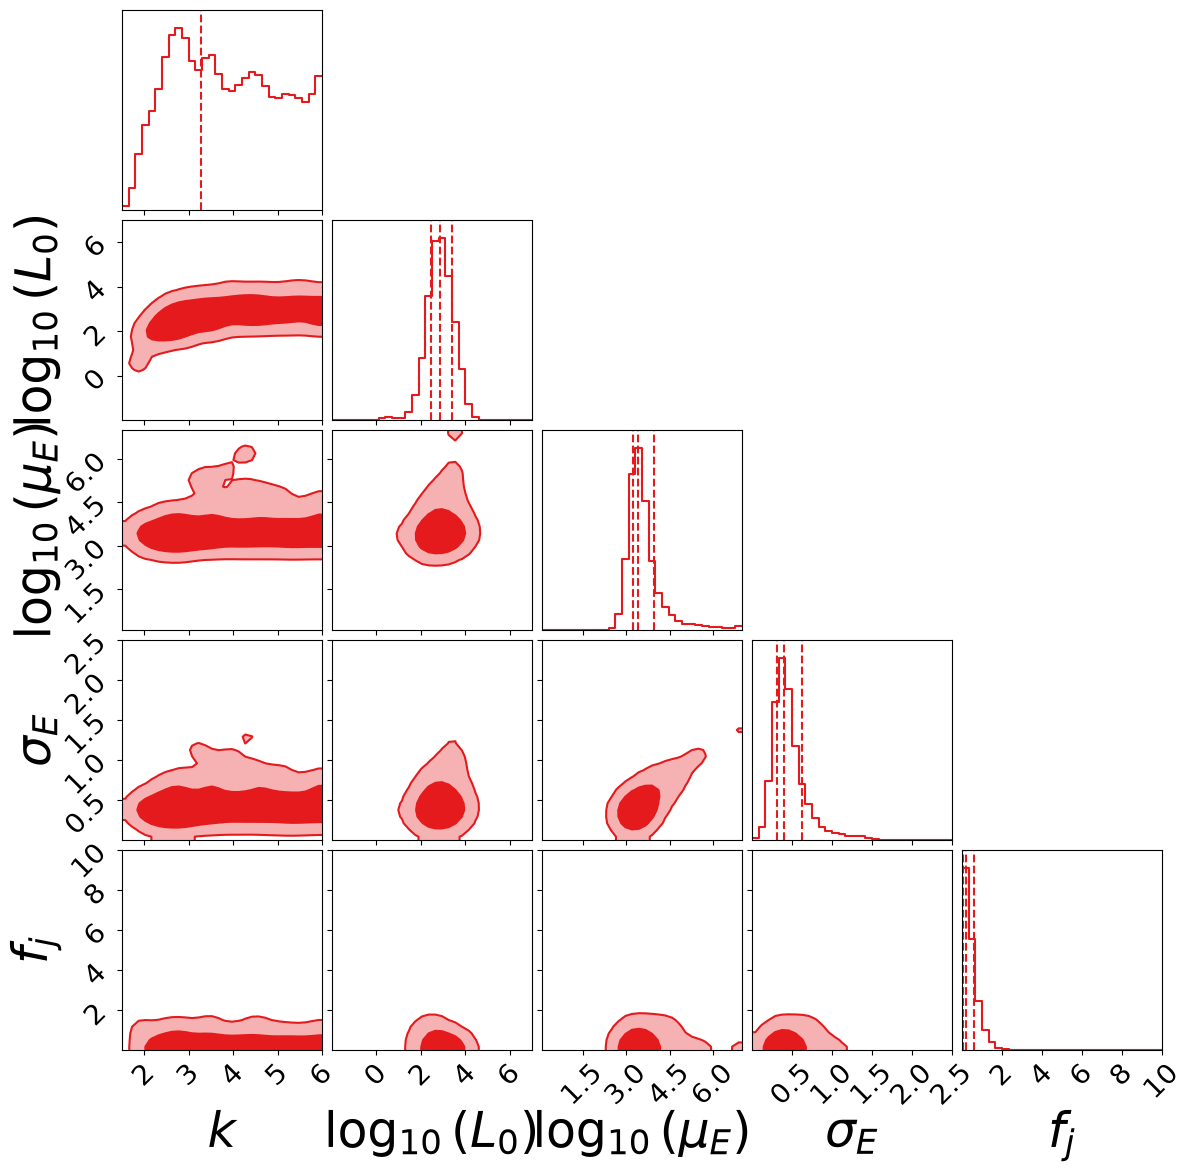

In [ ]:
plotter.plot_corner(filename="corner_flat_tophat.pdf")

In [10]:
#plotter.plot_cdf_comparison(
#    mc_func             = montecarlo,
#    bns_data            = bns_data,
#    observables         = observables,
##    geometric_eff_func  = geometric_efficiency_flat,
#    n_samples           = 100,
#    filename            = "cdf_flat_tophat.pdf"
#)

### Summary Table

In [15]:
print(plotter.summary_table())

\begin{tabular}{lc}
\hline
Parameter & Value \\
\hline
$k$ & $6.584_{-3.329}^{+3.699}$ \\
$\log_{10}(L_0)$ & $2.847_{-0.424}^{+0.552}$ \\
$\log_{10}(\mu_E)$ & $3.436_{-0.193}^{+0.527}$ \\
$\sigma_E$ & $0.411_{-0.090}^{+0.211}$ \\
$f_j$ & $0.217_{-0.170}^{+0.435}$ \\
\hline
\end{tabular}


### Autocorrelation

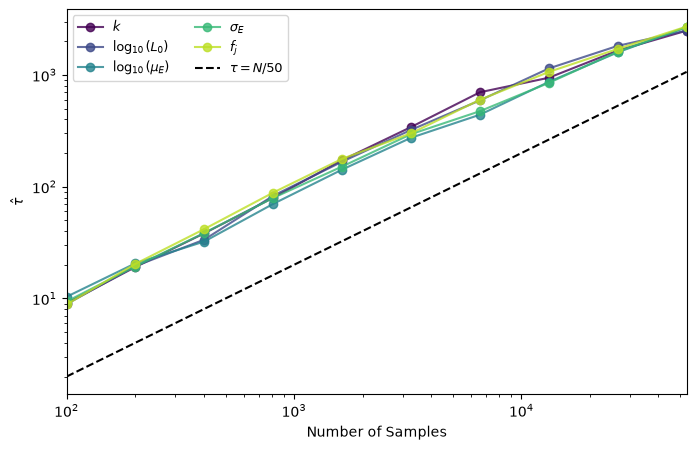

In [ ]:
plotter.plot_autocorrelation()